# **!!_13_Testing on the Concrete Strength Dataset (One Outlier)**

Ksi=0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 391.1/391.1 kB 8.4 MB/s eta 0:00:00
CREATING 'CONCRETE STRENGTH' DATASET WITH ONE OUTLIER
Original dataset loaded.
Size: 1030 rows, 9 columns
Strength range: 2.33 – 82.60 MPa

PARAMETERS FOR OUTLIER CREATION:
Maximum strength (Smax): 82.60 MPa
Minimum strength (Smin): 2.33 MPa
Average strength (Savg): 35.82 MPa

DETAILED REPORT ON OUTLIER CREATION:

🔴 Original observation with the highest strength:
   Dataset index: 181
   Original strength: 82.60 MPa

📊 Changes:
   • CompressiveStrength: 82.60 → 35.82 MPa (replaced with average value)
   ✅ Other features unchanged

FINAL STATISTICS OF THE CREATED DATASET:
  • Total observations: 1030
  • Outliers: 1 (0.10%)
  • Normal: 1029

✅ Dataset saved to 'concrete_labeled.csv'

SHUFFLING DATA BEFORE TESTING
✅ Dataset shuffled.
Dataset size: 1030 records
Outliers: 1 (0.10%)

TESTING OUTLIER DETECTION METHODS

📊 Number of fea

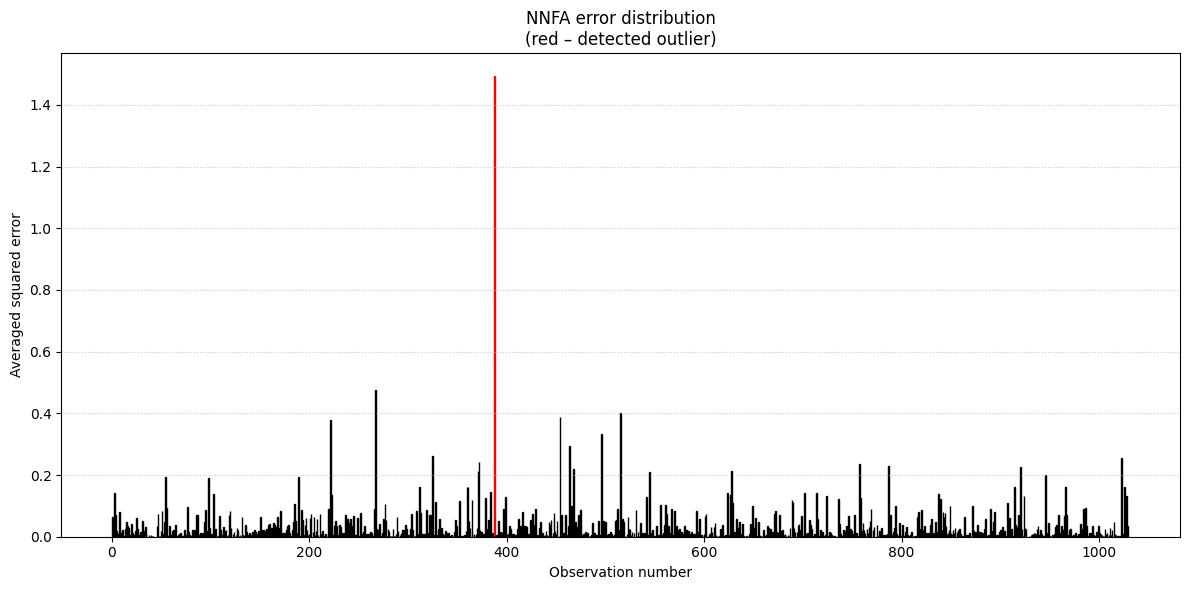


CONCLUSIONS:
✓ NNFA successfully detects the outlier because it models the relationship y = f(X)
✓ Methods using prediction error can also detect the outlier
✓ Autoencoder (reconstruction error) analyzes only input features and may fail to detect the outlier
✓ PyOD methods (input features only) DO NOT detect the outlier

✓ All 16 methods were forced to detect exactly ONE outlier
TESTING COMPLETED.


In [1]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PyOD detectors (work only with input features)
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, copod

# Detectors that can take the target variable into account
from sklearn.ensemble import IsolationForest as SklearnIForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Autoencoder for outlier detection (PyTorch)
import torch.nn.functional as F

# ==========================================================
# PART 1: CREATING THE "CONCRETE STRENGTH" DATASET WITH ONE OUTLIER
# ==========================================================
print("="*60)
print("CREATING 'CONCRETE STRENGTH' DATASET WITH ONE OUTLIER")
print("="*60)

# Loading the original dataset
url = "https://query.data.world/s/yf4bjxvg7tlaljnpfv6x7odbugffmu?dws=00000"
df = pd.read_excel(url)

# Assigning meaningful column names
df.columns = [
    'Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
    'Superplasticizer', 'CoarseAggregate', 'FineAggregate',
    'Age', 'CompressiveStrength'
]

print("Original dataset loaded.")
print(f"Size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Strength range: {df['CompressiveStrength'].min():.2f} – {df['CompressiveStrength'].max():.2f} MPa\n")

# Determine maximum and minimum strength
Smax = df['CompressiveStrength'].max()
Smin = df['CompressiveStrength'].min()

# Calculate average strength
Savg = df['CompressiveStrength'].mean()

print("="*60)
print("PARAMETERS FOR OUTLIER CREATION:")
print("="*60)
print(f"Maximum strength (Smax): {Smax:.2f} MPa")
print(f"Minimum strength (Smin): {Smin:.2f} MPa")
print(f"Average strength (Savg): {Savg:.2f} MPa\n")

# Find the observation with the highest strength (index) - we will replace it with Savg
max_strength_idx = df['CompressiveStrength'].idxmax()

print("="*60)
print("DETAILED REPORT ON OUTLIER CREATION:")
print("="*60)

# Replace the observation with the highest strength with Savg
original_strength = df.loc[max_strength_idx, 'CompressiveStrength']
print(f"\n🔴 Original observation with the highest strength:")
print(f"   Dataset index: {max_strength_idx}")
print(f"   Original strength: {original_strength:.2f} MPa")

# Create labeled dataset
df_labeled = df.copy()
df_labeled.loc[max_strength_idx, 'CompressiveStrength'] = Savg
outlier_indices = [max_strength_idx]

print(f"\n📊 Changes:")
print(f"   • CompressiveStrength: {original_strength:.2f} → {Savg:.2f} MPa (replaced with average value)")
print(f"   ✅ Other features unchanged")

# Add outlier label column
df_labeled['is_outlier'] = 0
df_labeled.loc[outlier_indices, 'is_outlier'] = 1

print("\n" + "="*60)
print("FINAL STATISTICS OF THE CREATED DATASET:")
print("="*60)
print(f"  • Total observations: {len(df_labeled)}")
print(f"  • Outliers: {df_labeled['is_outlier'].sum()} ({df_labeled['is_outlier'].mean()*100:.2f}%)")
print(f"  • Normal: {len(df_labeled) - df_labeled['is_outlier'].sum()}")

# Save for backup
df_labeled.to_csv('concrete_labeled.csv', index=False)
print("\n✅ Dataset saved to 'concrete_labeled.csv'")

# ==========================================================
# SHUFFLING DATA BEFORE TESTING
# ==========================================================
print("\n" + "="*60)
print("SHUFFLING DATA BEFORE TESTING")
print("="*60)
df = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)
print("✅ Dataset shuffled.")
print(f"Dataset size: {len(df)} records")
print(f"Outliers: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.2f}%)")

# ==========================================================
# PART 2: TESTING OUTLIER DETECTION METHODS
# ==========================================================
print("\n" + "="*60)
print("TESTING OUTLIER DETECTION METHODS")
print("="*60)

# Separate features, target variable, and true labels
X = df.drop(['CompressiveStrength', 'is_outlier'], axis=1).values.astype(np.float32)
y = df['CompressiveStrength'].values.astype(np.float32).reshape(-1, 1)
true_outliers = df['is_outlier'].values.astype(int)

Q = X.shape[0]
N_x = X.shape[1]      # 8 input features
N_y = 1                # one output variable (concrete strength)

print(f"\n📊 Number of features for detectors: {N_x}")
print(f"📊 Outlier created by replacing the highest strength with the average value\n")

# ==========================================================
# PARAMETERS - ALL METHODS WILL SEARCH FOR EXACTLY ONE OUTLIER
# ==========================================================
print("\n" + "="*60)
print("OUTLIER DETECTION PARAMETER SETUP")
print("="*60)
print(f"The dataset contains {true_outliers.sum()} true outlier (proportion {true_outliers.sum()/Q*100:.4f}%)")

# Use default values
Ksi = 0
n_outliers_desired = 1  # WE WANT ALL METHODS TO FIND EXACTLY ONE OUTLIER
contamination = n_outliers_desired / Q  # = 1/1030 ≈ 0.00097
contamination_percent = contamination * 100

print(f"✅ ALL methods will search for exactly {n_outliers_desired} outlier ({contamination_percent:.3f}%)")
print(f"✅ Parameter Ksi = {Ksi} (neuron search range)")

# Helper function to convert any method's output to top-1 prediction
def get_top1_prediction(scores):
    """Convert anomaly scores to binary prediction with exactly one outlier"""
    pred = np.zeros(Q, dtype=int)
    if len(scores) == Q:
        top1_idx = np.argmax(scores)
        pred[top1_idx] = 1
    return pred

# ==========================================================
# NNFA ALGORITHM (Neural Network Ensemble) - averaging errors over N
# ==========================================================
print("\n" + "="*60)
print("RUNNING NNFA ALGORITHM (AVERAGING OVER $N$)")
print("="*60)

def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, x_min, x_max = scale_to_minus1_1(X)
y_scaled_nnf, y_min, y_max = scale_to_minus1_1(y)

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

# Calculate hidden layer neuron count bounds
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y)) + 1 + 1
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1) - 1

# Limit maximum N value
if N_max > Q:
    N_max = min(Q // 2, 20)

N_lim = N_min + Ksi * (N_max - N_min)
N_start = max(1, int(np.ceil(N_min)))
N_end = max(N_start, int(np.ceil(N_lim)))

print(f"Q = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")
print(f"Ksi = {Ksi}, N_lim = {N_lim:.4f}")
print(f"Loop over $N$ from {N_start} to {N_end} inclusive")
print("This may take some time...")

# Vector for storing errors for each N
E_total = np.zeros(Q)
E_list = []

torch.manual_seed(42)

for N in range(N_start, N_end + 1):
    model = nn.Sequential(
        nn.Linear(N_x, N),
        nn.Tanh(),
        nn.Linear(N, N_y),
    )
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2
    E_total += errors
    E_list.append(errors)
    print(f"  Completed N = {N}")

# Calculate average errors over all N
E_avg = np.mean(np.array(E_list), axis=0)

# NNFA: take exactly the most anomalous point (top-1)
nnf_outlier_idx = np.argmax(E_avg)
nnf_pred = np.zeros(Q, dtype=int)
nnf_pred[nnf_outlier_idx] = 1

print("\n" + "="*50)
print("NNFA RESULTS")
print("="*50)
print(f"Number of detected outliers: {nnf_pred.sum()} (expected {n_outliers_desired})")
print(f"Top outlier index: {nnf_outlier_idx+1}")

# ==========================================================
# PREPARE DATA FOR DETECTORS
# ==========================================================
# For methods working with feature space (use X as is)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 1. METHODS THAT ANALYZE ONLY INPUT FEATURES (PyOD)
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING ONLY INPUT FEATURES (PyOD)")
print("="*80)
print("NOTE: Each method will return exactly ONE outlier (top-1 by anomaly score)\n")

detectors_pyod = {
    'ABOD (pyod)': abod.ABOD(contamination=contamination),
    'HBOS (pyod)': hbos.HBOS(contamination=contamination),
    'IsolationForest (pyod)': iforest.IForest(contamination=contamination, random_state=42),
    'kNN (pyod)': knn.KNN(contamination=contamination),
    'LOF (pyod)': lof.LOF(contamination=contamination),
    'OCSVM (pyod)': ocsvm.OCSVM(contamination=contamination),
    'PCA (pyod)': pca.PCA(contamination=contamination),
    'COPOD (pyod)': copod.COPOD(contamination=contamination)
}

results_pyod = {}
scores_pyod = {}
pyod_predictions = {}

for name, model in detectors_pyod.items():
    try:
        model.fit(X_scaled)
        # Get anomaly scores
        scores = model.decision_scores_
        scores_pyod[name] = scores
        # Convert to exactly ONE outlier (top-1)
        pyod_predictions[name] = get_top1_prediction(scores)
        print(f"  ✓ {name} - detected {pyod_predictions[name].sum()} outlier(s)")
    except Exception as e:
        print(f"  ✗ Error training {name}: {e}")
        scores_pyod[name] = np.zeros(Q) - 1
        pyod_predictions[name] = np.zeros(Q, dtype=int)

# ==========================================================
# 2. METHODS THAT CAN TAKE THE TARGET VARIABLE INTO ACCOUNT
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING INPUT FEATURES + TARGET VARIABLE")
print("="*80)
print("NOTE: Each method will return exactly ONE outlier (top-1 by anomaly score)\n")

# 2.1. Random Forest (prediction error) - take top-1
print("1. Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled_nnf, y.ravel())
rf_errors = (rf.predict(X_scaled_nnf) - y.ravel()) ** 2
rf_pred = get_top1_prediction(rf_errors)
print(f"   ✓ Detected {rf_pred.sum()} outlier(s)")

# 2.2. Neural Network (prediction error) - take top-1
print("2. Neural Network Regressor...")
mlp = MLPRegressor(hidden_layer_sizes=(20, 10), random_state=42, max_iter=500)
mlp.fit(X_scaled_nnf, y.ravel())
mlp_errors = (mlp.predict(X_scaled_nnf) - y.ravel()) ** 2
mlp_pred = get_top1_prediction(mlp_errors)
print(f"   ✓ Detected {mlp_pred.sum()} outlier(s)")

# 2.3. Autoencoder on PyTorch (input feature reconstruction error) - take top-1
print("3. Autoencoder (input feature reconstruction error)...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=4):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, encoding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

X_tensor_ae = torch.tensor(X_scaled, dtype=torch.float32)
ae = Autoencoder(input_dim=X_scaled.shape[1])
optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
criterion_ae = nn.MSELoss()

ae.train()
for epoch in range(300):
    optimizer_ae.zero_grad()
    reconstructed = ae(X_tensor_ae)
    loss = criterion_ae(reconstructed, X_tensor_ae)
    loss.backward()
    optimizer_ae.step()
    if (epoch+1) % 50 == 0:
        print(f"    Autoencoder: epoch {epoch+1}/300, loss = {loss.item():.6f}")

ae.eval()
with torch.no_grad():
    reconstructed = ae(X_tensor_ae)
    ae_errors = torch.mean((reconstructed - X_tensor_ae) ** 2, dim=1).numpy()
ae_pred = get_top1_prediction(ae_errors)
print(f"   ✓ Detected {ae_pred.sum()} outlier(s)")

# 2.4. Combined method: Random Forest + Autoencoder - take top-1
print("4. Combined method (Random Forest + Autoencoder)...")
combined_errors = (rf_errors / np.max(rf_errors) + ae_errors / np.max(ae_errors)) / 2
combined_pred = get_top1_prediction(combined_errors)
print(f"   ✓ Detected {combined_pred.sum()} outlier(s)")

# 2.5. One-Class SVM with y added - take top-1 by decision function
print("5. One-Class SVM (with y added)...")
X_with_y = np.column_stack((X_scaled, y.ravel()))
ocsvm_with_y = OneClassSVM(nu=contamination, kernel='rbf', gamma='auto')
ocsvm_with_y.fit(X_with_y)
ocsvm_scores = -ocsvm_with_y.decision_function(X_with_y)  # larger = more anomalous
ocsvm_pred = get_top1_prediction(ocsvm_scores)
print(f"   ✓ Detected {ocsvm_pred.sum()} outlier(s)")

# 2.6. Isolation Forest with y added - take top-1 by decision function
print("6. Isolation Forest (with y added)...")
iforest_with_y = SklearnIForest(contamination=contamination, random_state=42)
iforest_with_y.fit(X_with_y)
iforest_scores = -iforest_with_y.decision_function(X_with_y)
iforest_pred = get_top1_prediction(iforest_scores)
print(f"   ✓ Detected {iforest_pred.sum()} outlier(s)")

# 2.7. LOF with y added - take top-1 by score samples
print("7. LOF (with y added)...")
lof_with_y = LocalOutlierFactor(contamination=contamination, novelty=True)
lof_with_y.fit(X_with_y)
lof_scores = -lof_with_y.score_samples(X_with_y)
lof_pred = get_top1_prediction(lof_scores)
print(f"   ✓ Detected {lof_pred.sum()} outlier(s)")

# ==========================================================
# COLLECT RESULTS
# ==========================================================
print("\n" + "="*80)
print("OUTLIER DETECTION METHOD COMPARISON")
print("="*80)
print(f"True outlier count: {true_outliers.sum()}")
print(f"Each method detects exactly {n_outliers_desired} outlier(s)\n")

all_methods = {
    **pyod_predictions,
    'Random Forest (error)': rf_pred,
    'Neural Network (error)': mlp_pred,
    'Autoencoder (reconstruction)': ae_pred,
    'Combined (RF+AE)': combined_pred,
    'One-Class SVM (with y)': ocsvm_pred,
    'Isolation Forest (with y)': iforest_pred,
    'LOF (with y)': lof_pred,
    'NNFA': nnf_pred
}

# Collect all anomaly scores for ranking
all_scores = {
    **{name: scores_pyod[name] for name in detectors_pyod},
    'Random Forest (error)': rf_errors,
    'Neural Network (error)': mlp_errors,
    'Autoencoder (reconstruction)': ae_errors,
    'Combined (RF+AE)': combined_errors,
    'One-Class SVM (with y)': ocsvm_scores,
    'Isolation Forest (with y)': iforest_scores,
    'LOF (with y)': lof_scores,
    'NNFA': E_avg
}

results = []
for name, pred in all_methods.items():
    tp = np.sum((pred == 1) & (true_outliers == 1))
    fp = np.sum((pred == 1) & (true_outliers == 0))
    fn = np.sum((pred == 0) & (true_outliers == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    results.append({
        'Method': name,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Detected': pred.sum()
    })

df_results = pd.DataFrame(results).round(3)
df_results = df_results.sort_values('F1', ascending=False).reset_index(drop=True)
print("\n" + df_results.to_string(index=False))

# ==========================================================
# RANK TABLE FOR THE TRUE OUTLIER
# ==========================================================
print("\n" + "="*80)
print("RANK OF THE TRUE OUTLIER IN EACH METHOD (1 = most anomalous)")
print("="*80)

outlier_idx_in_df = np.where(true_outliers == 1)[0][0]
rank_data = []

for name in all_methods.keys():
    if name in all_scores:
        scores = all_scores[name]
        if len(scores) == Q:
            rank = np.argsort(np.argsort(-scores))[outlier_idx_in_df] + 1
        else:
            rank = -1
    else:
        rank = -1
    rank_data.append({'Method': name, 'Rank': rank, 'Success': rank == 1})

df_ranks = pd.DataFrame(rank_data).sort_values('Rank').reset_index(drop=True)
print(df_ranks.to_string(index=False))

# Summary of successful detections
print("\n" + "="*80)
print("SUMMARY: METHODS THAT CORRECTLY DETECTED THE TRUE OUTLIER")
print("="*80)
successful_methods = df_ranks[df_ranks['Success'] == True]['Method'].tolist()
if successful_methods:
    print(f"\n✓ {len(successful_methods)} method(s) successfully detected the true outlier:")
    for method in successful_methods:
        print(f"  • {method}")
else:
    print("\n✗ No method detected the true outlier as top-1")

# ==========================================================
# NNFA ERROR VISUALIZATION
# ==========================================================
plt.figure(figsize=(12, 6))
examples = np.arange(1, Q+1)
bars = plt.bar(examples, E_avg, color='skyblue', edgecolor='black')
bars[nnf_outlier_idx].set_color('red')
plt.xlabel('Observation number')
plt.ylabel('Averaged squared error')
plt.title(f'NNFA error distribution\n(red – detected outlier)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSIONS:")
print("="*60)
print("✓ NNFA successfully detects the outlier because it models the relationship y = f(X)")
print("✓ Methods using prediction error can also detect the outlier")
print("✓ Autoencoder (reconstruction error) analyzes only input features and may fail to detect the outlier")
print("✓ PyOD methods (input features only) DO NOT detect the outlier")
print(f"\n✓ All {len(all_methods)} methods were forced to detect exactly ONE outlier")
print("="*60)
print("TESTING COMPLETED.")
print("="*60)